In [1]:
!nvidia-smi

Fri Apr 10 23:39:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5500               On  |   00000000:43:00.0 Off |                  Off |
| 30%   34C    P8             20W /  230W |      32MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# PyMC Sampler Comparison: Cython (Metropolis) vs JAX (NUTS) — batchscan & batchvmap

This notebook compares three PyMC workflows for Bayesian inference in the aDDM using the **same transformed-space posterior** as the reference Bayesian example in `example4_new/addm_inference.ipynb`.

1. **Cython + Metropolis**: PyMC Metropolis targeting the transformed-space posterior with the Cython likelihood
2. **JAX batchscan + NUTS**: PyMC + NumPyro NUTS with the JAX likelihood (scan-based batching)
3. **JAX batchvmap + NUTS**: PyMC + NumPyro NUTS with the JAX likelihood (vmap-based batching)

In [1]:
import os
import sys
import time
import datetime
import numpy as np

# Add src to path
src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

from pytensor.graph.op import Op

# JAX imports
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

from efficient_fpt.jax import set_jax_precision

set_jax_precision(True)

print(f"PyMC version: {pm.__version__}")
print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

PyMC version: 5.28.2
JAX version: 0.9.1
JAX devices: [CudaDevice(id=0)]


## Configuration

In [2]:
# =====================================================================
# Configuration
# =====================================================================
DATA_PATH = "../example4_new/addm_data_20251015-163921.npz"

# Data subset (use smaller for testing, larger for real comparison)
NUM_TRIALS = 500  # Number of trials to use

# Sampling configuration
N_DRAWS = 500      # Number of posterior draws per chain
N_TUNE = 200       # Number of tuning steps
N_CHAINS = 2       # Number of chains

# Cython configuration
NUM_THREADS = 32    # OpenMP threads for Cython
PYMC_CORES = 1     # Avoid forking a multithreaded JAX process

# JAX configuration
TRUNC_NUM = 10      # Fixed truncation length used in this notebook
JAX_USE_REMAT = False

# Random seed for reproducibility
RANDOM_SEED = 42

## Load Data

In [3]:
# =====================================================================
# Load and prepare data using canonical loader
# =====================================================================
from efficient_fpt.io import load_addm_experiment

data = load_addm_experiment(DATA_PATH)
params = data["params"]
decision = data["decision_data"]
covariates = data["covariates"]

# True parameters
TRUE_PARAMS = {
    'eta': float(params["eta"]),
    'kappa': float(params["kappa"]),
    'a': float(params["a"]),
    'b': float(params["b"]),
    'x0': float(params["x0"]),
    'sigma': float(params["sigma"]),
}

# Extract data arrays
r1_full = covariates["r1_data"].astype(np.float64)
r2_full = covariates["r2_data"].astype(np.float64)
flag_full = covariates["flag_data"].astype(np.int32)
sacc_full = covariates["sacc_array_data"].astype(np.float64)
d_full = covariates["d_data"].astype(np.int32)
rt_full = decision["rt_data"].astype(np.float64)
choice_full = decision["choice_data"].astype(np.int32)

num_data_full = len(rt_full)
max_d = int(d_full.max())

# Subset to NUM_TRIALS
idx = slice(0, min(NUM_TRIALS, num_data_full))
r1_data = r1_full[idx]
r2_data = r2_full[idx]
flag_data = flag_full[idx]
sacc_data = sacc_full[idx]
d_data = d_full[idx]
rt_data = rt_full[idx]
choice_data = choice_full[idx]

num_data = len(rt_data)
sigma = TRUE_PARAMS['sigma']
M = float(np.max(rt_data))  # Max RT for constraints

print(f"Data loaded: {num_data} trials, max_d={max_d}")
print(f"Max RT: {M:.4f}")
print(f"\nTrue parameters:")
for k, v in TRUE_PARAMS.items():
    print(f"  {k}: {v}")


Data loaded: 500 trials, max_d=12
Max RT: 4.8855

True parameters:
  eta: 0.7
  kappa: 0.5
  a: 2.1
  b: 0.3
  x0: -0.2
  sigma: 1.0


## 1. Cython Implementation (Transformed-Space Metropolis)

This uses a custom PyTensor Op wrapping the Cython likelihood, but the PyMC model is written in the **same unconstrained parameterization** as the reference Bayesian notebook. Metropolis therefore samples the transformed variables rather than making random walks directly in constrained parameter space.


In [4]:
# Import Cython implementation
from efficient_fpt.cython import compute_addm_mean_nll, print_num_threads

print("Cython implementation loaded.")
print_num_threads()

Cython implementation loaded.
Number of available threads: 64


In [5]:
class LogLikeCython(Op):
    """
    PyTensor Op wrapping the Cython likelihood function.
    
    Input: theta = [eta, kappa, a, b, x0]
    Output: scalar log-likelihood
    
    NOTE: No grad() method defined = gradient-free only!
    """
    itypes = [pt.dvector]
    otypes = [pt.dscalar]

    def __init__(self, rt_data, choice_data, r1_data, r2_data, flag_data,
                 sacc_data, d_data, sigma, n_threads=8):
        self.rt_data = np.asarray(rt_data, dtype=np.float64)
        self.choice_data = np.asarray(choice_data, dtype=np.int32)
        self.r1_data = np.asarray(r1_data, dtype=np.float64)
        self.r2_data = np.asarray(r2_data, dtype=np.float64)
        self.flag_data = np.asarray(flag_data, dtype=np.int32)
        self.sacc_data = np.asarray(sacc_data, dtype=np.float64)
        self.d_data = np.asarray(d_data, dtype=np.int32)
        self.sigma = float(sigma)
        self.num_data = len(self.rt_data)
        self.n_threads = int(n_threads)

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta

        # Compute negative log-likelihood
        nll = compute_addm_mean_nll(
            self.rt_data, self.choice_data,
            eta, kappa, self.sigma, a, b, x0,
            self.r1_data, self.r2_data, self.flag_data,
            self.sacc_data, self.d_data,
            order_mid=30, order_last=30,
            n_threads=self.n_threads,
            log_space=True,
        )
        
        # Return log-likelihood (negative of NLL)
        loglik = -self.num_data * nll
        outputs[0][0] = np.array(loglik, dtype="float64")


# Create the Cython Op
cython_loglike_op = LogLikeCython(
    rt_data=rt_data, choice_data=choice_data,
    r1_data=r1_data, r2_data=r2_data, flag_data=flag_data,
    sacc_data=sacc_data, d_data=d_data,
    sigma=sigma, n_threads=NUM_THREADS,
)

# Test it
theta_true = np.array([TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'], 
                       TRUE_PARAMS['a'], TRUE_PARAMS['b'], TRUE_PARAMS['x0']])
theta_sym = pt.dvector("theta")
ll_cython = pytensor.function([theta_sym], cython_loglike_op(theta_sym))

print(f"Cython log-likelihood at true params: {ll_cython(theta_true):.4f}")

Cython log-likelihood at true params: -749.6751


## 2. JAX Implementation (Same Posterior, With Gradients) — batchscan & batchvmap

This uses the JAX-based likelihood with automatic differentiation, but keeps the **same transformed-space posterior and priors** as the Cython/PyMC model. We build both `batchscan` and `batchvmap` variants to compare their NUTS sampling performance.

In [6]:
# Import both public JAX batch NLL factories
from efficient_fpt.jax import (
    make_addm_nll_function_batchscan,
    make_addm_nll_function_batchvmap,
)

print("JAX implementation loaded (batchscan + batchvmap).")

JAX implementation loaded (batchscan + batchvmap).


In [7]:
print(
    f"Building both batchscan and batchvmap NLL closures "
    f"(trunc_num={TRUNC_NUM}, use_remat={JAX_USE_REMAT})"
)

Building both batchscan and batchvmap NLL closures (trunc_num=10, use_remat=False)


In [8]:
common_kwargs = dict(
    rt_data=rt_data,
    choice_data=choice_data,
    r1_data=r1_data,
    r2_data=r2_data,
    flag_data=flag_data,
    sacc_array_data=sacc_data,
    d_data=d_data,
    order_mid=30,
    order_last=30,
    trunc_num=TRUNC_NUM,
    log_space=True,
    use_remat=JAX_USE_REMAT,
)

jax_sum_nll_batchscan = make_addm_nll_function_batchscan(**common_kwargs)
jax_sum_nll_batchvmap = make_addm_nll_function_batchvmap(**common_kwargs)

def make_loglik_and_grad(sum_nll_fn):
    def loglik(eta, kappa, a, b, x0):
        return -sum_nll_fn(eta, kappa, sigma, a, b, x0)
    return jit(loglik), jit(grad(loglik, argnums=(0, 1, 2, 3, 4)))

jax_loglik_batchscan, jax_grad_batchscan = make_loglik_and_grad(jax_sum_nll_batchscan)
jax_loglik_batchvmap, jax_grad_batchvmap = make_loglik_and_grad(jax_sum_nll_batchvmap)

# Warm up both
print("Warming up JAX JIT compilation...")
true_args = (TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'],
             TRUE_PARAMS['a'], TRUE_PARAMS['b'], TRUE_PARAMS['x0'])
for name, ll_fn, g_fn in [("batchscan", jax_loglik_batchscan, jax_grad_batchscan),
                           ("batchvmap", jax_loglik_batchvmap, jax_grad_batchvmap)]:
    _ = ll_fn(*true_args)
    _ = g_fn(*true_args)
    ll_val = float(ll_fn(*true_args))
    print(f"  {name} log-likelihood at true params: {ll_val:.4f}")

print("Done.")

Warming up JAX JIT compilation...
  batchscan log-likelihood at true params: -749.6751
  batchvmap log-likelihood at true params: -749.6751
Done.


In [9]:
from pytensor.link.jax.dispatch import jax_funcify

class LogLikeJAX(Op):
    """
    PyTensor Op wrapping a JAX likelihood function WITH GRADIENTS.
    Enables NUTS sampling by providing gradient information.
    """
    itypes = [pt.dvector]
    otypes = [pt.dscalar]

    def __init__(self, loglik_fn, grad_fn):
        self.loglik_fn = loglik_fn
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        loglik = float(self.loglik_fn(eta, kappa, a, b, x0))
        outputs[0][0] = np.array(loglik, dtype="float64")

    def grad(self, inputs, output_grads):
        (theta,) = inputs
        (g_out,) = output_grads
        grads = LogLikeJAXGrad(self.grad_fn)(theta)
        return [g_out * grads]


class LogLikeJAXGrad(Op):
    """Gradient Op for the JAX likelihood."""
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, grad_fn):
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        grads = self.grad_fn(eta, kappa, a, b, x0)
        outputs[0][0] = np.array([float(g) for g in grads], dtype="float64")


# Register JAX implementations for numpyro backend
@jax_funcify.register(LogLikeJAX)
def jax_funcify_LogLikeJAX(op, **kwargs):
    loglik_fn = op.loglik_fn
    def loglik_jax(theta):
        return loglik_fn(theta[0], theta[1], theta[2], theta[3], theta[4])
    return loglik_jax

@jax_funcify.register(LogLikeJAXGrad)
def jax_funcify_LogLikeJAXGrad(op, **kwargs):
    grad_fn = op.grad_fn
    def grad_jax(theta):
        return jnp.stack(grad_fn(theta[0], theta[1], theta[2], theta[3], theta[4]))
    return grad_jax


# Create one Op per variant
jax_loglike_op_batchscan = LogLikeJAX(jax_loglik_batchscan, jax_grad_batchscan)
jax_loglike_op_batchvmap = LogLikeJAX(jax_loglik_batchvmap, jax_grad_batchvmap)

# Test both
theta_sym = pt.dvector("theta")
for name, op in [("batchscan", jax_loglike_op_batchscan),
                 ("batchvmap", jax_loglike_op_batchvmap)]:
    fn = pytensor.function([theta_sym], op(theta_sym))
    print(f"JAX {name} Op log-likelihood at true params: {fn(theta_true):.4f}")

JAX batchscan Op log-likelihood at true params: -749.6751
JAX batchvmap Op log-likelihood at true params: -749.6751


## 3. Compare Likelihood Evaluation Speed

In [10]:
def time_fn(fn, *args, n=20):
    """Time a function over n calls."""
    start = time.perf_counter()
    for _ in range(n):
        _ = fn(*args)
    elapsed = time.perf_counter() - start
    return elapsed / n

print("=" * 60)
print("Likelihood Evaluation Timing")
print("=" * 60)

# Cython timing
t_cython = time_fn(ll_cython, theta_true, n=20)
print(f"Cython:                {t_cython*1000:.2f} ms per evaluation")

# JAX timing for both variants
for name, ll_fn, g_fn in [("batchscan", jax_loglik_batchscan, jax_grad_batchscan),
                           ("batchvmap", jax_loglik_batchvmap, jax_grad_batchvmap)]:
    t_ll = time_fn(
        lambda t, _fn=ll_fn: float(_fn(t[0], t[1], t[2], t[3], t[4])),
        theta_true, n=20,
    )
    print(f"JAX {name} (loglik):  {t_ll*1000:.2f} ms ({t_cython/t_ll:.1f}x vs Cython)")

    t_grad = time_fn(
        lambda t, _fn=ll_fn, _gfn=g_fn: (_fn(t[0], t[1], t[2], t[3], t[4]),
                                           _gfn(t[0], t[1], t[2], t[3], t[4])),
        theta_true, n=20,
    )
    print(f"JAX {name} (+grad):  {t_grad*1000:.2f} ms")

Likelihood Evaluation Timing
Cython:                3.61 ms per evaluation
JAX batchscan (loglik):  22.26 ms (0.2x vs Cython)
JAX batchscan (+grad):  921.06 ms
JAX batchvmap (loglik):  36.68 ms (0.1x vs Cython)
JAX batchvmap (+grad):  740.61 ms


## 4. Build PyMC Models

In [11]:
def z_to_u_np(z):
    """Map constrained parameters z=(eta, kappa, a, b, x0) to unconstrained u-space."""
    eta, kappa, a, b, x0 = [float(v) for v in z]
    tb = b * M / a
    sx = (x0 + a) / (2.0 * a)
    return np.array([
        np.log(eta) - np.log1p(-eta),
        np.log(kappa),
        np.log(a),
        np.log(tb) - np.log1p(-tb),
        np.log(sx) - np.log1p(-sx),
    ], dtype=np.float64)


def build_pymc_model(loglike_op, name_suffix=""):
    """
    Build a PyMC model on the same unconstrained parameterization used by
    the reference Bayesian notebook in example4_new/addm_inference.ipynb.
    """
    init_u = z_to_u_np([
        TRUE_PARAMS["eta"], TRUE_PARAMS["kappa"], TRUE_PARAMS["a"],
        TRUE_PARAMS["b"], TRUE_PARAMS["x0"],
    ])

    with pm.Model() as model:
        u_eta = pm.Flat(f"u_eta{name_suffix}", initval=float(init_u[0]))
        u_kappa = pm.Flat(f"u_kappa{name_suffix}", initval=float(init_u[1]))
        u_a = pm.Flat(f"u_a{name_suffix}", initval=float(init_u[2]))
        u_b = pm.Flat(f"u_b{name_suffix}", initval=float(init_u[3]))
        u_x0 = pm.Flat(f"u_x0{name_suffix}", initval=float(init_u[4]))

        eta = pm.Deterministic(f"eta{name_suffix}", pm.math.sigmoid(u_eta))
        kappa = pm.Deterministic(f"kappa{name_suffix}", pt.exp(u_kappa))
        a = pm.Deterministic(f"a{name_suffix}", pt.exp(u_a))
        tb = pm.math.sigmoid(u_b)
        b = pm.Deterministic(f"b{name_suffix}", (a / M) * tb)
        sx = pm.math.sigmoid(u_x0)
        x0 = pm.Deterministic(f"x0{name_suffix}", -a + 2.0 * a * sx)

        theta = pt.stack([eta, kappa, a, b, x0])

        log_prior = (
            pm.logp(pm.Beta.dist(alpha=2.0, beta=2.0), eta)
            + pm.logp(pm.Gamma.dist(alpha=2.0, beta=4.0), kappa)
            + pm.logp(pm.Gamma.dist(alpha=2.0, beta=1.0), a)
            + pm.logp(pm.Beta.dist(alpha=2.0, beta=2.0), tb) - pt.log(a / M)
            + pm.logp(pm.Beta.dist(alpha=2.0, beta=2.0), sx) - pt.log(2.0 * a)
        )

        log_jac = (
            pt.log(eta) + pt.log1p(-eta)
            + pt.log(kappa)
            + pt.log(a)
            + pt.log(a / M) + pt.log(tb) + pt.log1p(-tb)
            + pt.log(2.0 * a) + pt.log(sx) + pt.log1p(-sx)
        )

        pm.Potential(f"logpost{name_suffix}", loglike_op(theta) + log_prior + log_jac)

    return model


print("Building PyMC models on transformed space...")
model_cython = build_pymc_model(cython_loglike_op, "_cy")
model_jax_scan = build_pymc_model(jax_loglike_op_batchscan, "_scan")
model_jax_vmap = build_pymc_model(jax_loglike_op_batchvmap, "_vmap")
print("Done: 3 models (Cython, JAX batchscan, JAX batchvmap)")

Building PyMC models on transformed space...
Done: 3 models (Cython, JAX batchscan, JAX batchvmap)


## 5. Run Cython + Metropolis Sampling on the Transformed Posterior


In [12]:
print("=" * 60)
print("Cython + Metropolis Sampling")
print("=" * 60)
print(f"Configuration: {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started at: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_cython:
    t_start = time.perf_counter()

    trace_cython = pm.sample(
        draws=N_DRAWS,
        tune=N_TUNE,
        chains=N_CHAINS,
        cores=PYMC_CORES,
        # PyMC builds one scalar Metropolis step per unconstrained variable here,
        # so the transformed-space random-walk scale must be a scalar, not a length-5 vector.
        step=pm.Metropolis(
            vars=[
                model_cython['u_eta_cy'], model_cython['u_kappa_cy'],
                model_cython['u_a_cy'], model_cython['u_b_cy'], model_cython['u_x0_cy'],
            ],
            scaling=0.012,
        ),
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )

    t_cython_sample = time.perf_counter() - t_start

print(f"\nFinished at: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total sampling time: {t_cython_sample:.1f} s")
print(f"Time per sample: {t_cython_sample / (N_DRAWS * N_CHAINS) * 1000:.1f} ms")


Cython + Metropolis Sampling
Configuration: 500 draws, 200 tune, 2 chains
Started at: 22:45:45


Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [u_eta_cy]
>Metropolis: [u_kappa_cy]
>Metropolis: [u_a_cy]
>Metropolis: [u_b_cy]
>Metropolis: [u_x0_cy]


Output()

Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 49 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Finished at: 22:46:37
Total sampling time: 52.8 s
Time per sample: 52.8 ms


## 6. Run JAX + NUTS Sampling — batchscan & batchvmap

Because the JAX likelihood Ops provide gradients, we can sample the **same transformed-space posterior** with NUTS. We run both batch variants back-to-back.

In [13]:
jax_traces = {}
jax_sample_times = {}

for variant_name, model_jax in [("batchscan", model_jax_scan),
                                 ("batchvmap", model_jax_vmap)]:
    print("=" * 60)
    print(f"JAX + NUTS ({variant_name}, numpyro backend)")
    print("=" * 60)
    print(f"Configuration: {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
    print(f"Started at: {datetime.datetime.now().strftime('%H:%M:%S')}")

    with model_jax:
        t_start = time.perf_counter()

        trace = pm.sample(
            draws=N_DRAWS,
            tune=N_TUNE,
            chains=N_CHAINS,
            nuts_sampler="numpyro",
            nuts_sampler_kwargs={"chain_method": "vectorized"},
            random_seed=RANDOM_SEED,
            progressbar=True,
            return_inferencedata=True,
        )

        elapsed = time.perf_counter() - t_start

    jax_traces[variant_name] = trace
    jax_sample_times[variant_name] = elapsed

    print(f"Finished at: {datetime.datetime.now().strftime('%H:%M:%S')}")
    print(f"Total sampling time: {elapsed:.1f} s")
    print(f"Time per sample: {elapsed / (N_DRAWS * N_CHAINS) * 1000:.1f} ms")
    print()

JAX + NUTS (batchscan, numpyro backend)
Configuration: 500 draws, 200 tune, 2 chains
Started at: 22:46:43


sample: 100%|██████████| 700/700 [26:13<00:00,  2.25s/it]  
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Finished at: 23:13:29
Total sampling time: 1606.0 s
Time per sample: 1606.0 ms

JAX + NUTS (batchvmap, numpyro backend)
Configuration: 500 draws, 200 tune, 2 chains
Started at: 23:13:29


sample: 100%|██████████| 700/700 [18:38<00:00,  1.60s/it]  
We recommend running at least 4 chains for robust computation of convergence diagnostics


Finished at: 23:32:29
Total sampling time: 1140.2 s
Time per sample: 1140.2 ms



## 7. Compare Results

In [14]:
print("=" * 60)
print("Sampling Performance Comparison")
print("=" * 60)

print(f"\nCython + Metropolis:")
print(f"  Total time: {t_cython_sample:.1f} s")
print(f"  Time per sample: {t_cython_sample / (N_DRAWS * N_CHAINS) * 1000:.1f} ms")

for vname, t_jax in jax_sample_times.items():
    print(f"\nJAX + NUTS ({vname}):")
    print(f"  Total time: {t_jax:.1f} s")
    print(f"  Time per sample: {t_jax / (N_DRAWS * N_CHAINS) * 1000:.1f} ms")
    print(f"  vs Cython: {t_cython_sample / t_jax:.2f}x")

Sampling Performance Comparison

Cython + Metropolis:
  Total time: 52.8 s
  Time per sample: 52.8 ms

JAX + NUTS (batchscan):
  Total time: 1606.0 s
  Time per sample: 1606.0 ms
  vs Cython: 0.03x

JAX + NUTS (batchvmap):
  Total time: 1140.2 s
  Time per sample: 1140.2 ms
  vs Cython: 0.05x


In [15]:
# Rename variables for comparison
trace_cython_renamed = trace_cython.rename({
    'eta_cy': 'eta', 'kappa_cy': 'kappa', 'a_cy': 'a', 'b_cy': 'b', 'x0_cy': 'x0'
})

jax_traces_renamed = {}
for vname, trace in jax_traces.items():
    suffix = "_scan" if vname == "batchscan" else "_vmap"
    jax_traces_renamed[vname] = trace.rename({
        f'eta{suffix}': 'eta', f'kappa{suffix}': 'kappa',
        f'a{suffix}': 'a', f'b{suffix}': 'b', f'x0{suffix}': 'x0',
    })

params = ['eta', 'kappa', 'a', 'b', 'x0']

print("\n" + "=" * 60)
print("Parameter Estimates Comparison")
print("=" * 60)

header = f"{'Param':<8} {'True':<10} {'Cython':<12}"
for vname in jax_traces_renamed:
    header += f" {'JAX '+vname:<16}"
print(f"\n{header}")
print("-" * len(header))

for param in params:
    true_val = TRUE_PARAMS[param]
    cy_mean = float(trace_cython_renamed.posterior[param].mean())
    row = f"{param:<8} {true_val:<10.4f} {cy_mean:<12.4f}"
    for vname, tr in jax_traces_renamed.items():
        jax_mean = float(tr.posterior[param].mean())
        row += f" {jax_mean:<16.4f}"
    print(row)


Parameter Estimates Comparison

Param    True       Cython       JAX batchscan    JAX batchvmap   
------------------------------------------------------------------
eta      0.7000     0.7265       0.7270           0.7251          
kappa    0.5000     0.4898       0.4866           0.4866          
a        2.1000     2.0612       2.0531           2.0535          
b        0.3000     0.2858       0.2818           0.2807          
x0       -0.2000    -0.1973      -0.1967          -0.1967         


In [16]:
print("\n" + "=" * 60)
print("Effective Samples per Second")
print("=" * 60)

header = f"{'Param':<8} {'Cython ESS/s':<15}"
for vname in jax_traces_renamed:
    header += f" {vname+' ESS/s':<18}"
print(f"\n{header}")
print("-" * len(header))

for param in params:
    cy_ess = float(az.ess(trace_cython_renamed, var_names=[param])[param])
    cy_ess_per_s = cy_ess / t_cython_sample
    row = f"{param:<8} {cy_ess_per_s:<15.2f}"
    for vname, tr in jax_traces_renamed.items():
        jax_ess = float(az.ess(tr, var_names=[param])[param])
        jax_ess_per_s = jax_ess / jax_sample_times[vname]
        row += f" {jax_ess_per_s:<18.2f}"
    print(row)


Effective Samples per Second

Param    Cython ESS/s    batchscan ESS/s    batchvmap ESS/s   
--------------------------------------------------------------
eta      1.04            0.74               1.12              
kappa    0.54            0.57               0.84              
a        0.93            0.40               0.65              
b        1.05            0.39               0.60              
x0       0.50            0.55               0.78              


## 8. Diagnostic Plots

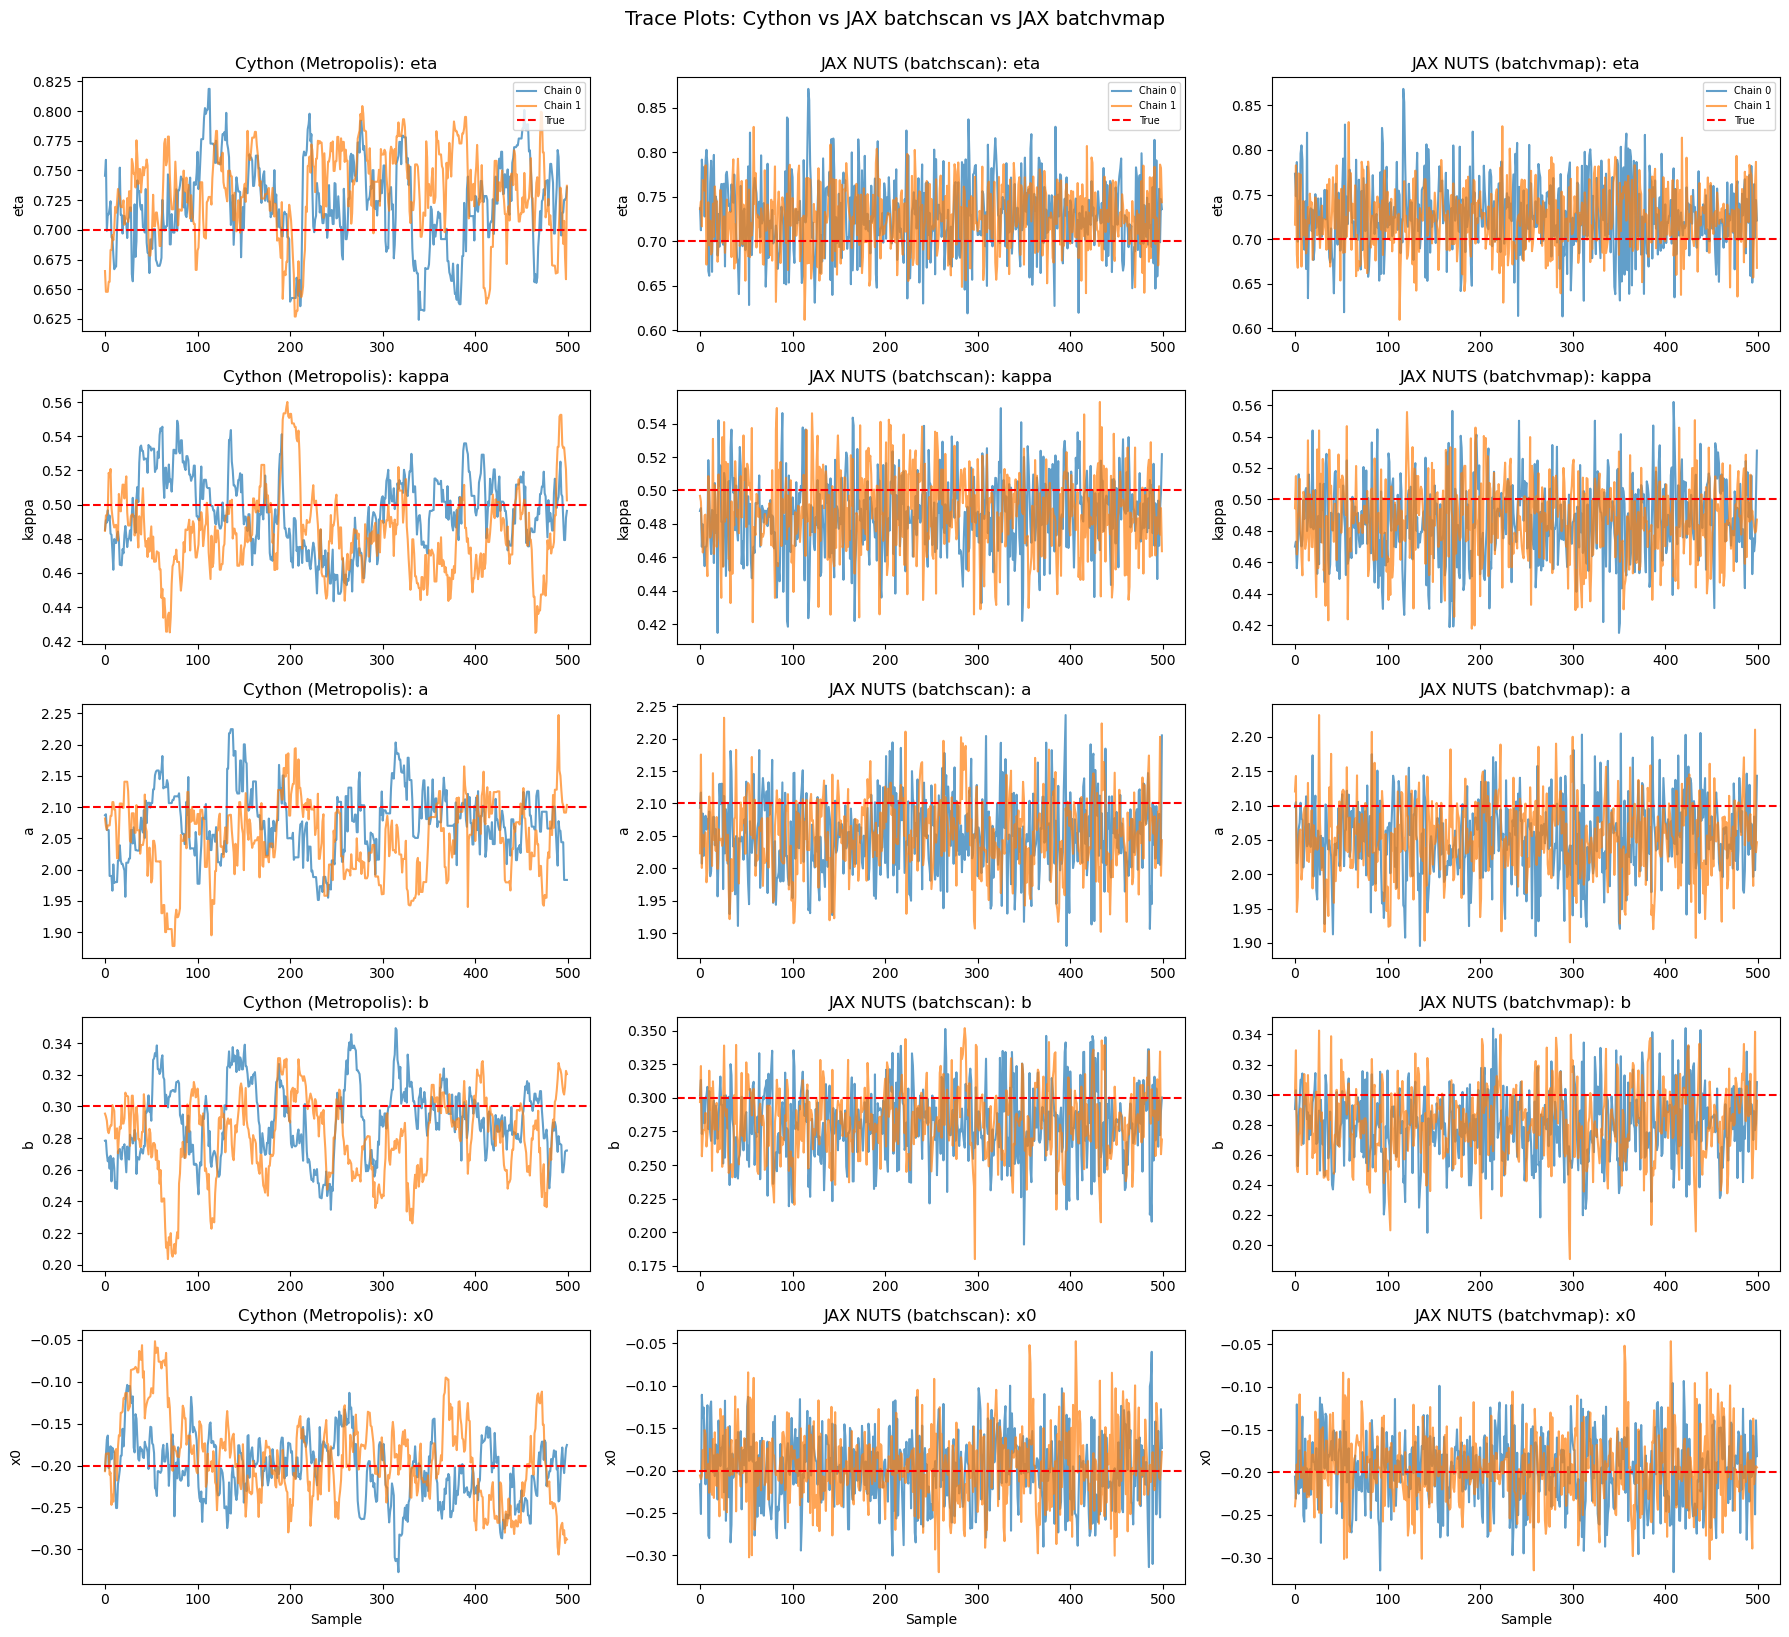

In [17]:
fig, axes = plt.subplots(5, 3, figsize=(18, 16))

all_traces = [("Cython (Metropolis)", trace_cython_renamed, t_cython_sample)]
for vname, tr in jax_traces_renamed.items():
    all_traces.append((f"JAX NUTS ({vname})", tr, jax_sample_times[vname]))

for i, param in enumerate(params):
    for j, (label, trace, _) in enumerate(all_traces):
        ax = axes[i, j]
        for chain in range(N_CHAINS):
            ax.plot(trace.posterior[param].sel(chain=chain).values,
                    alpha=0.7, label=f'Chain {chain}')
        ax.axhline(TRUE_PARAMS[param], color='red', linestyle='--', label='True')
        ax.set_ylabel(param)
        ax.set_title(f'{label}: {param}')
        if i == 0:
            ax.legend(loc='upper right', fontsize=7)

for j in range(3):
    axes[-1, j].set_xlabel('Sample')

plt.tight_layout()
plt.suptitle('Trace Plots: Cython vs JAX batchscan vs JAX batchvmap', y=1.02, fontsize=14)
plt.show()

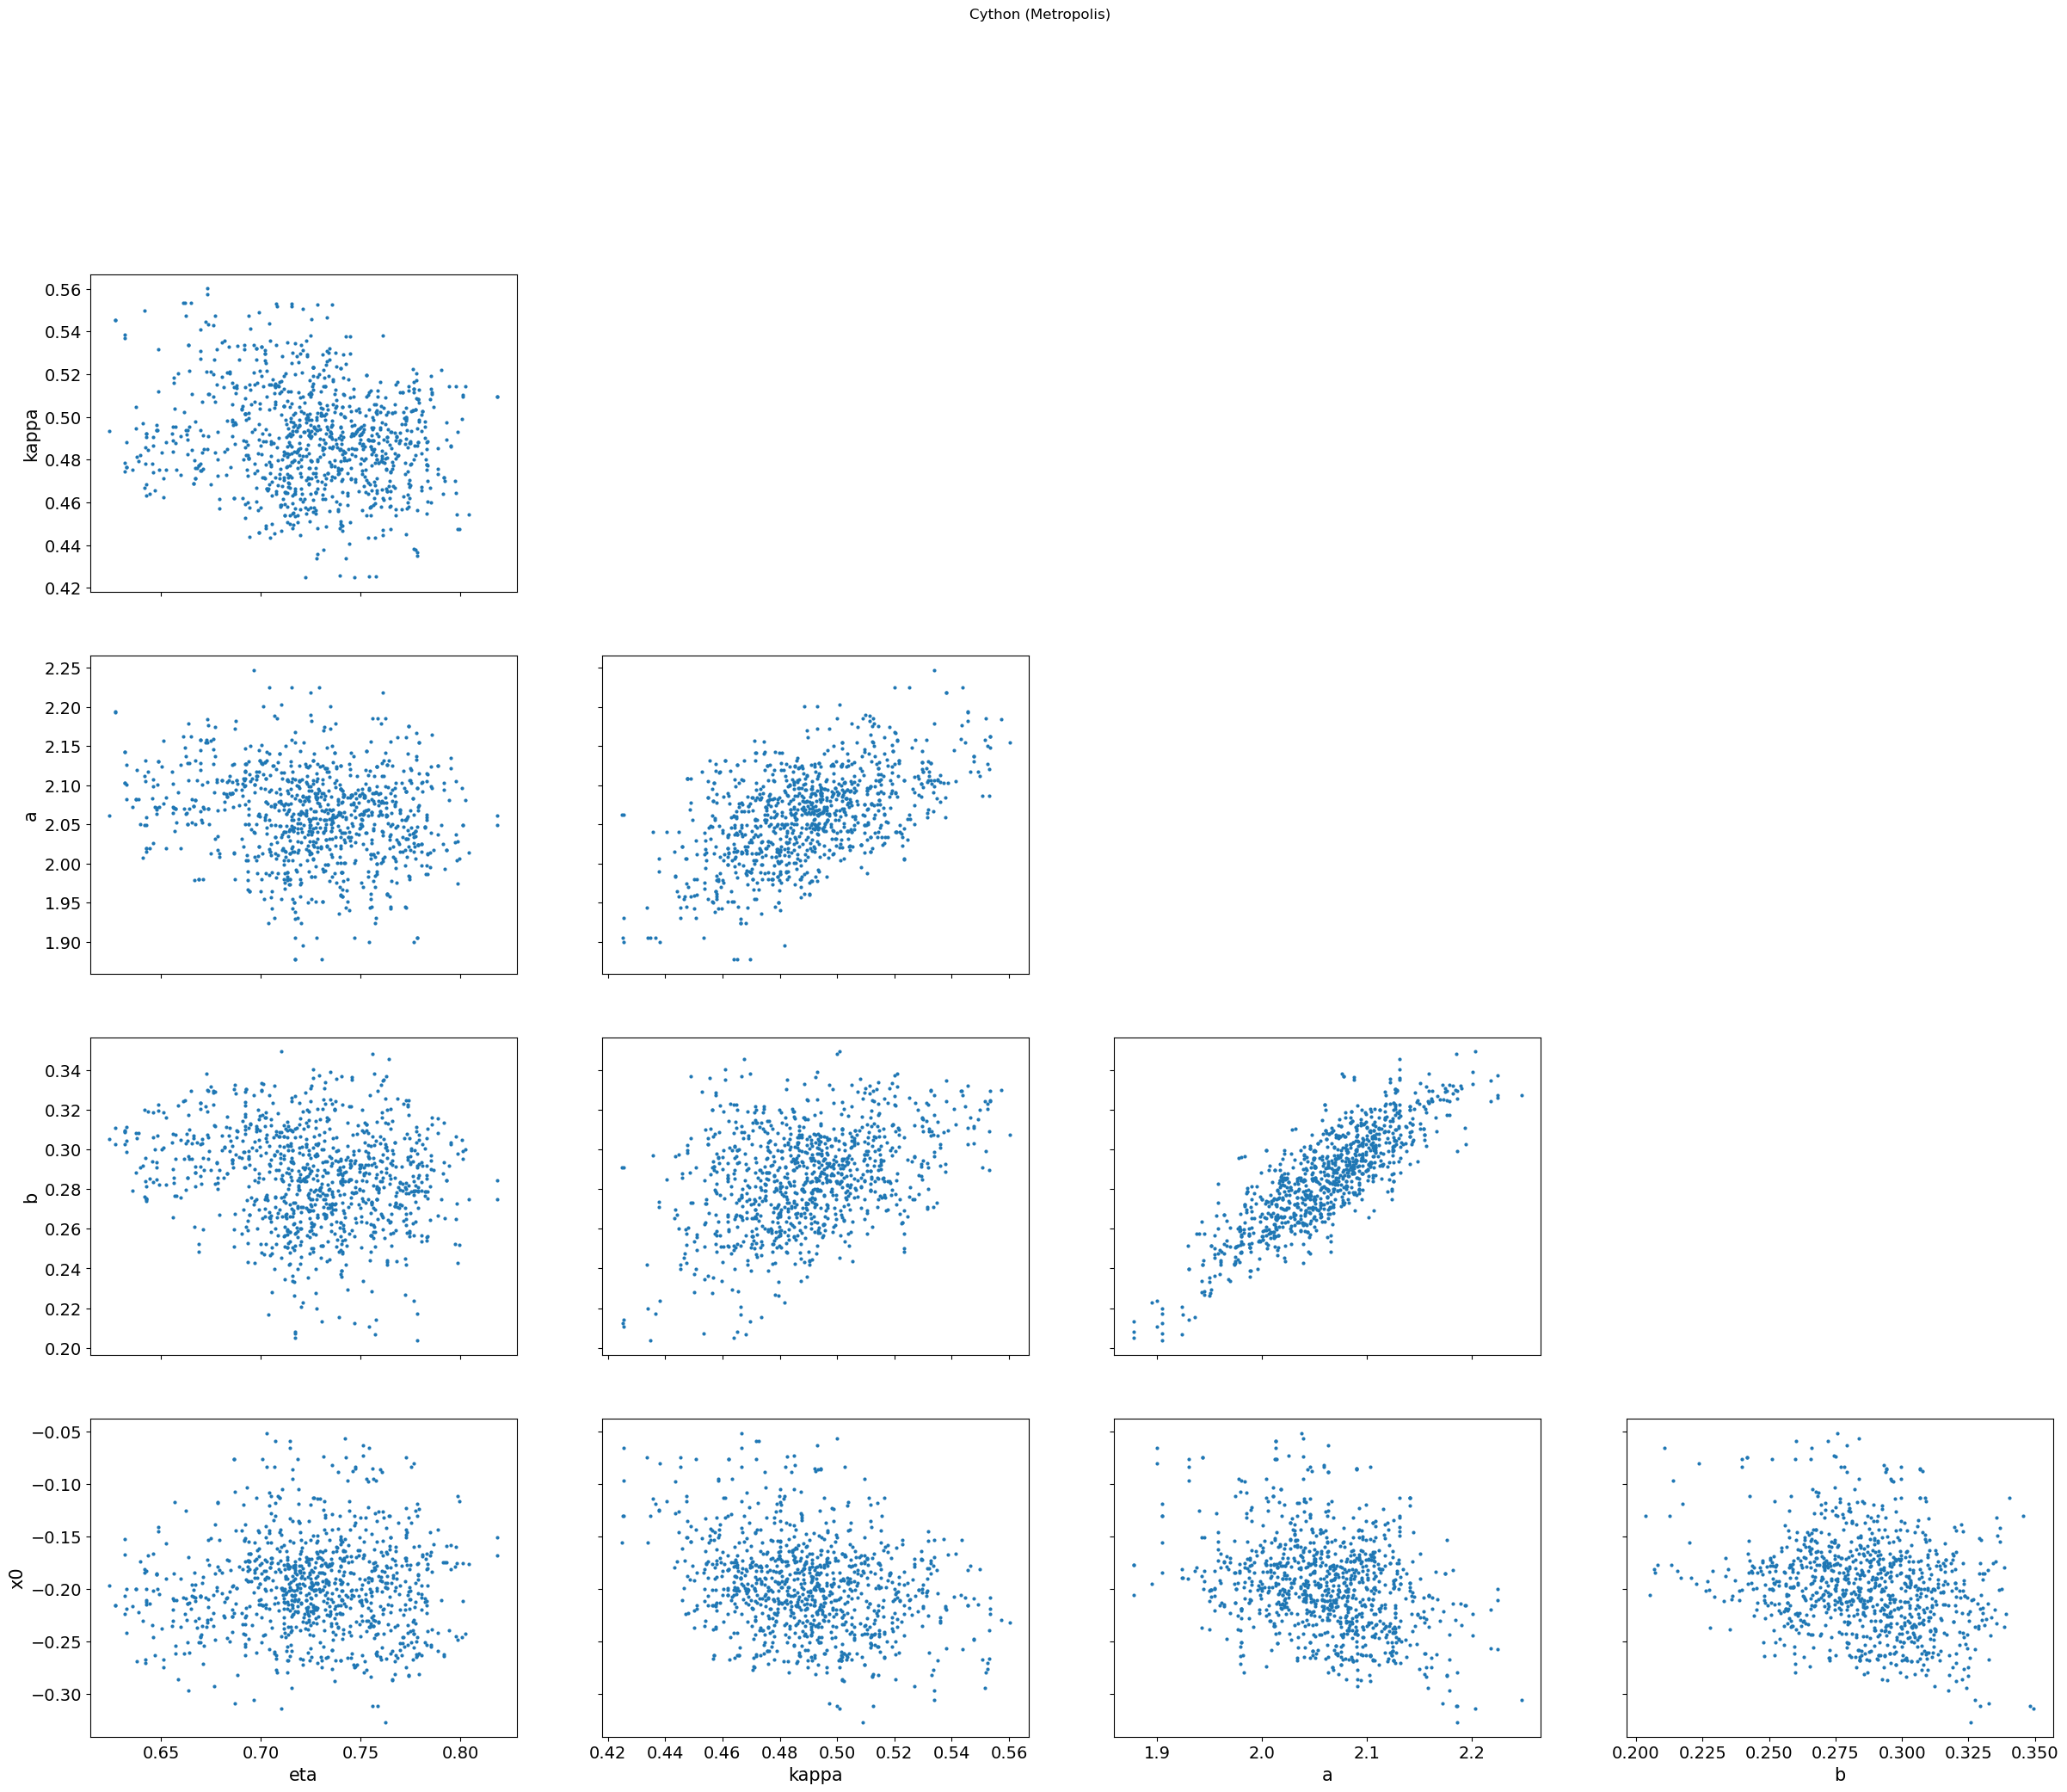

In [18]:
az.plot_pair(trace_cython_renamed, var_names=params)
plt.suptitle("Cython (Metropolis)", y=1.02)
plt.show()

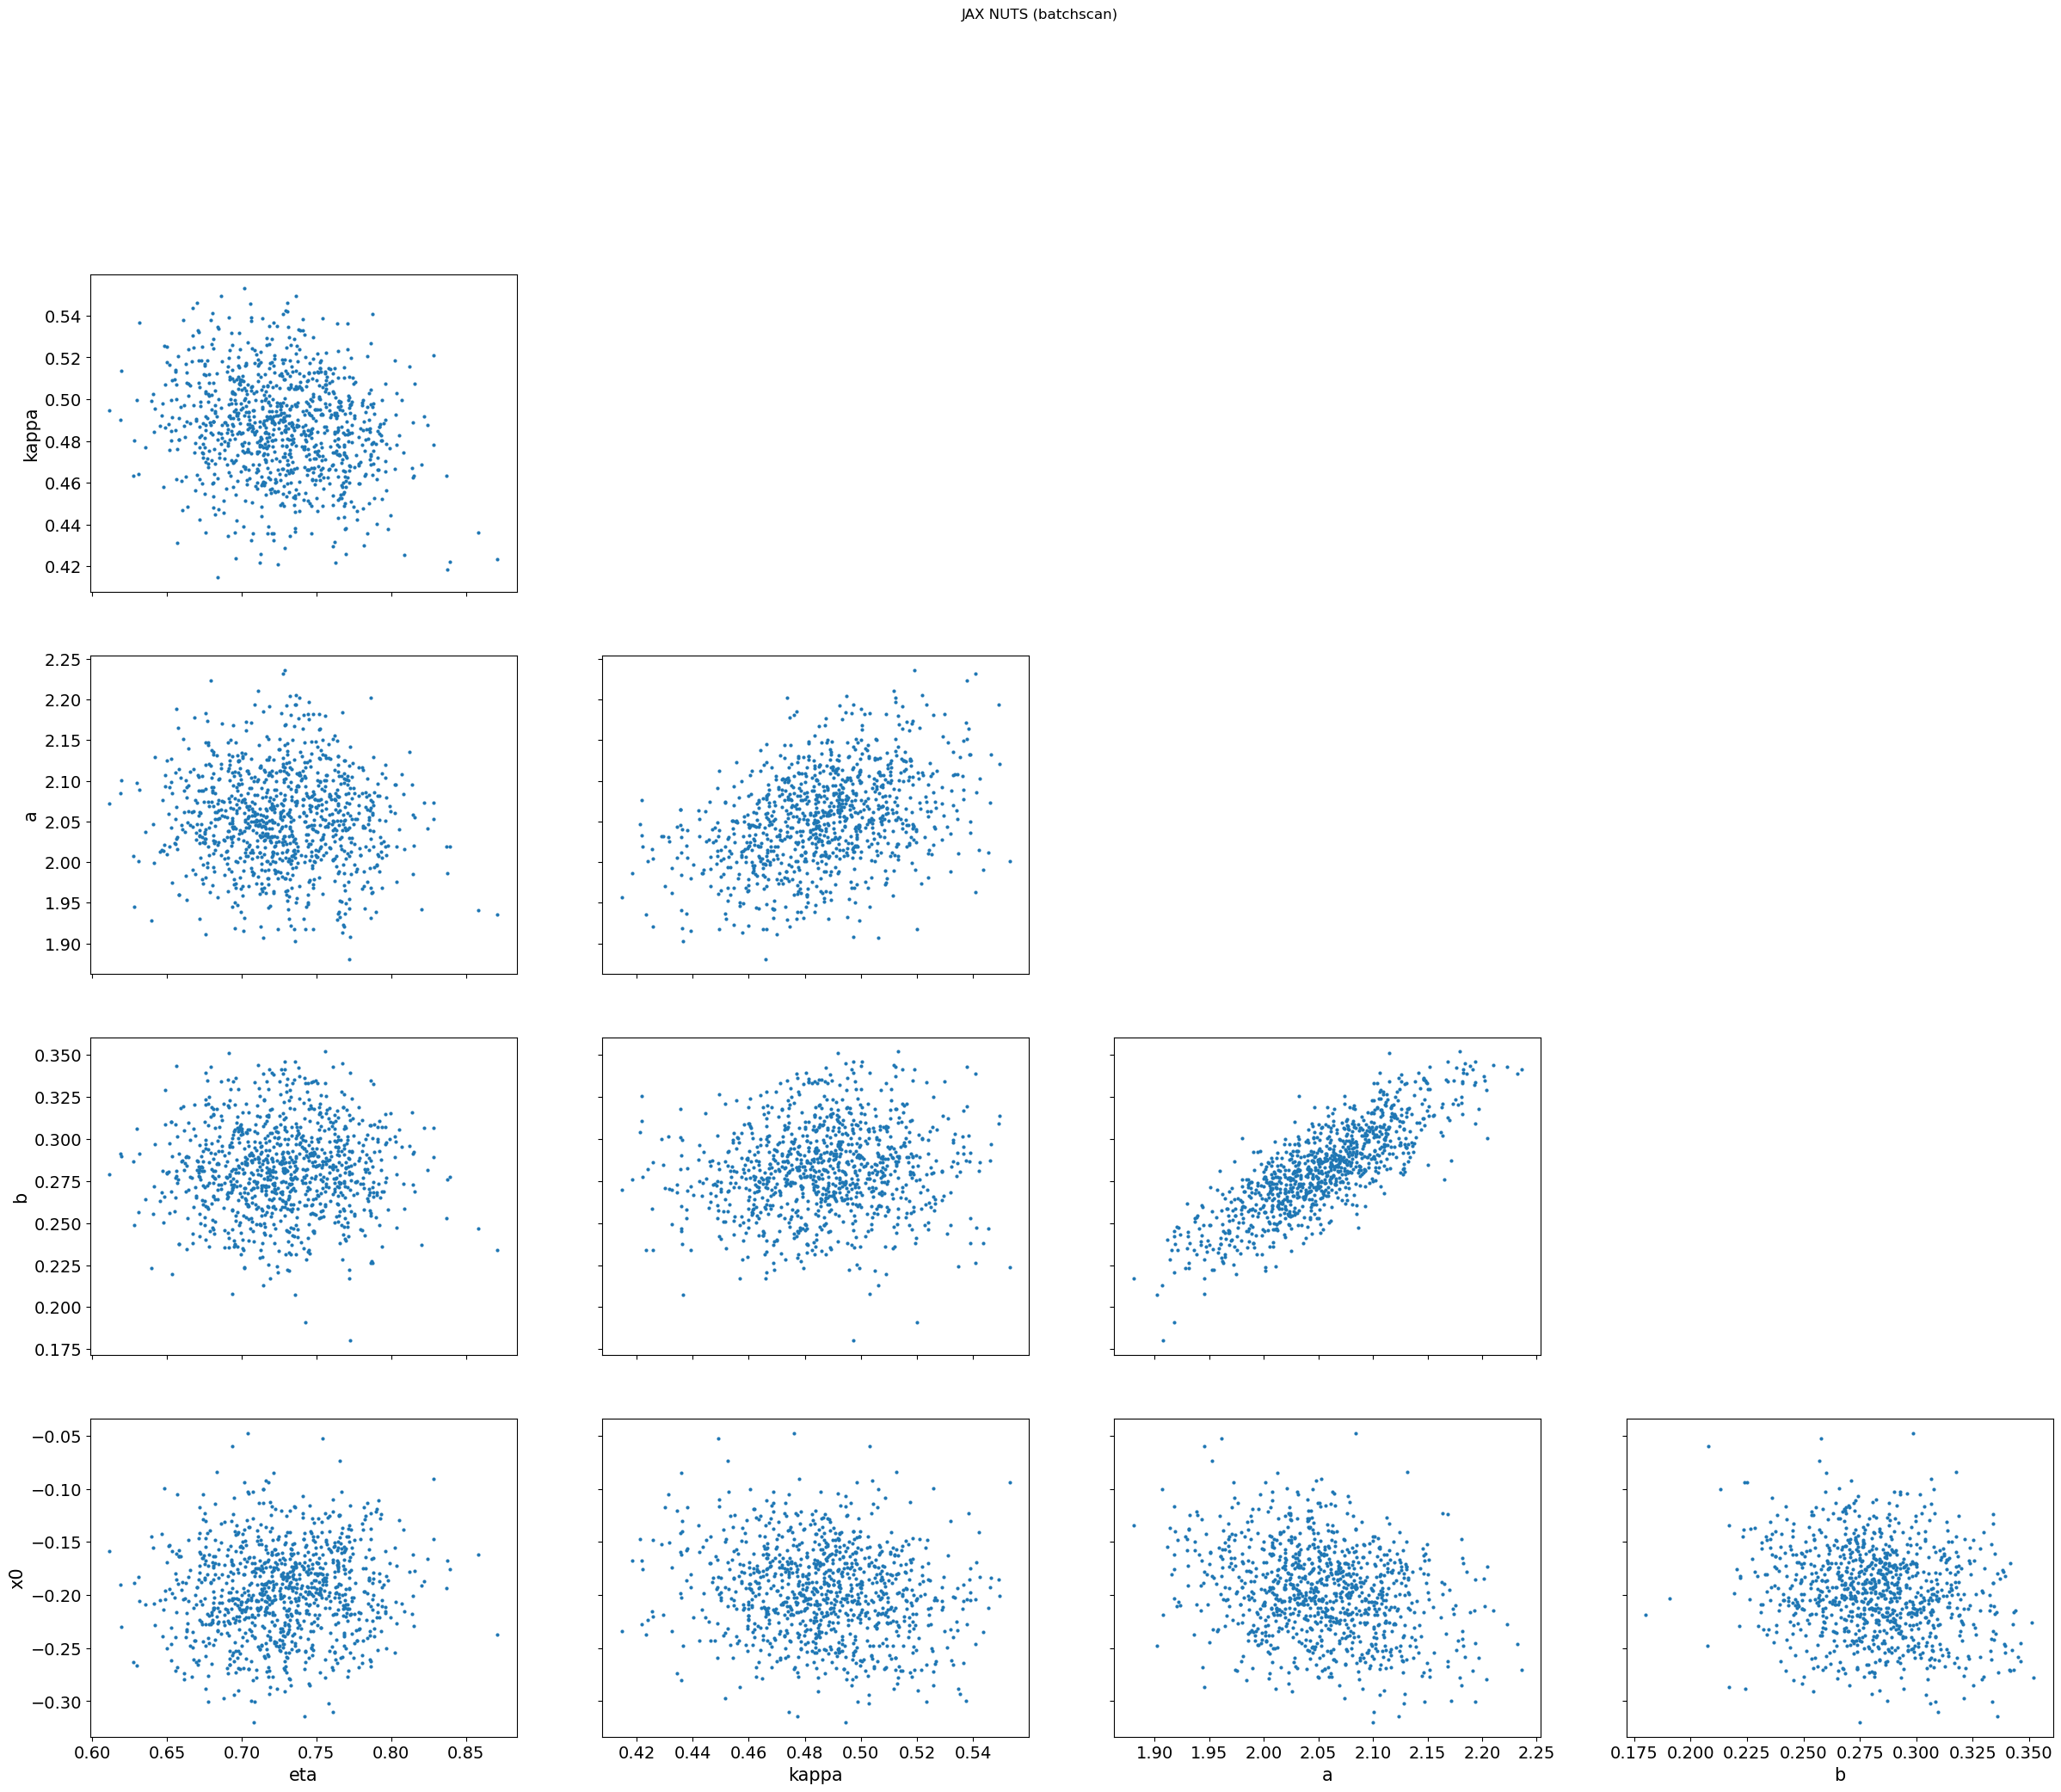

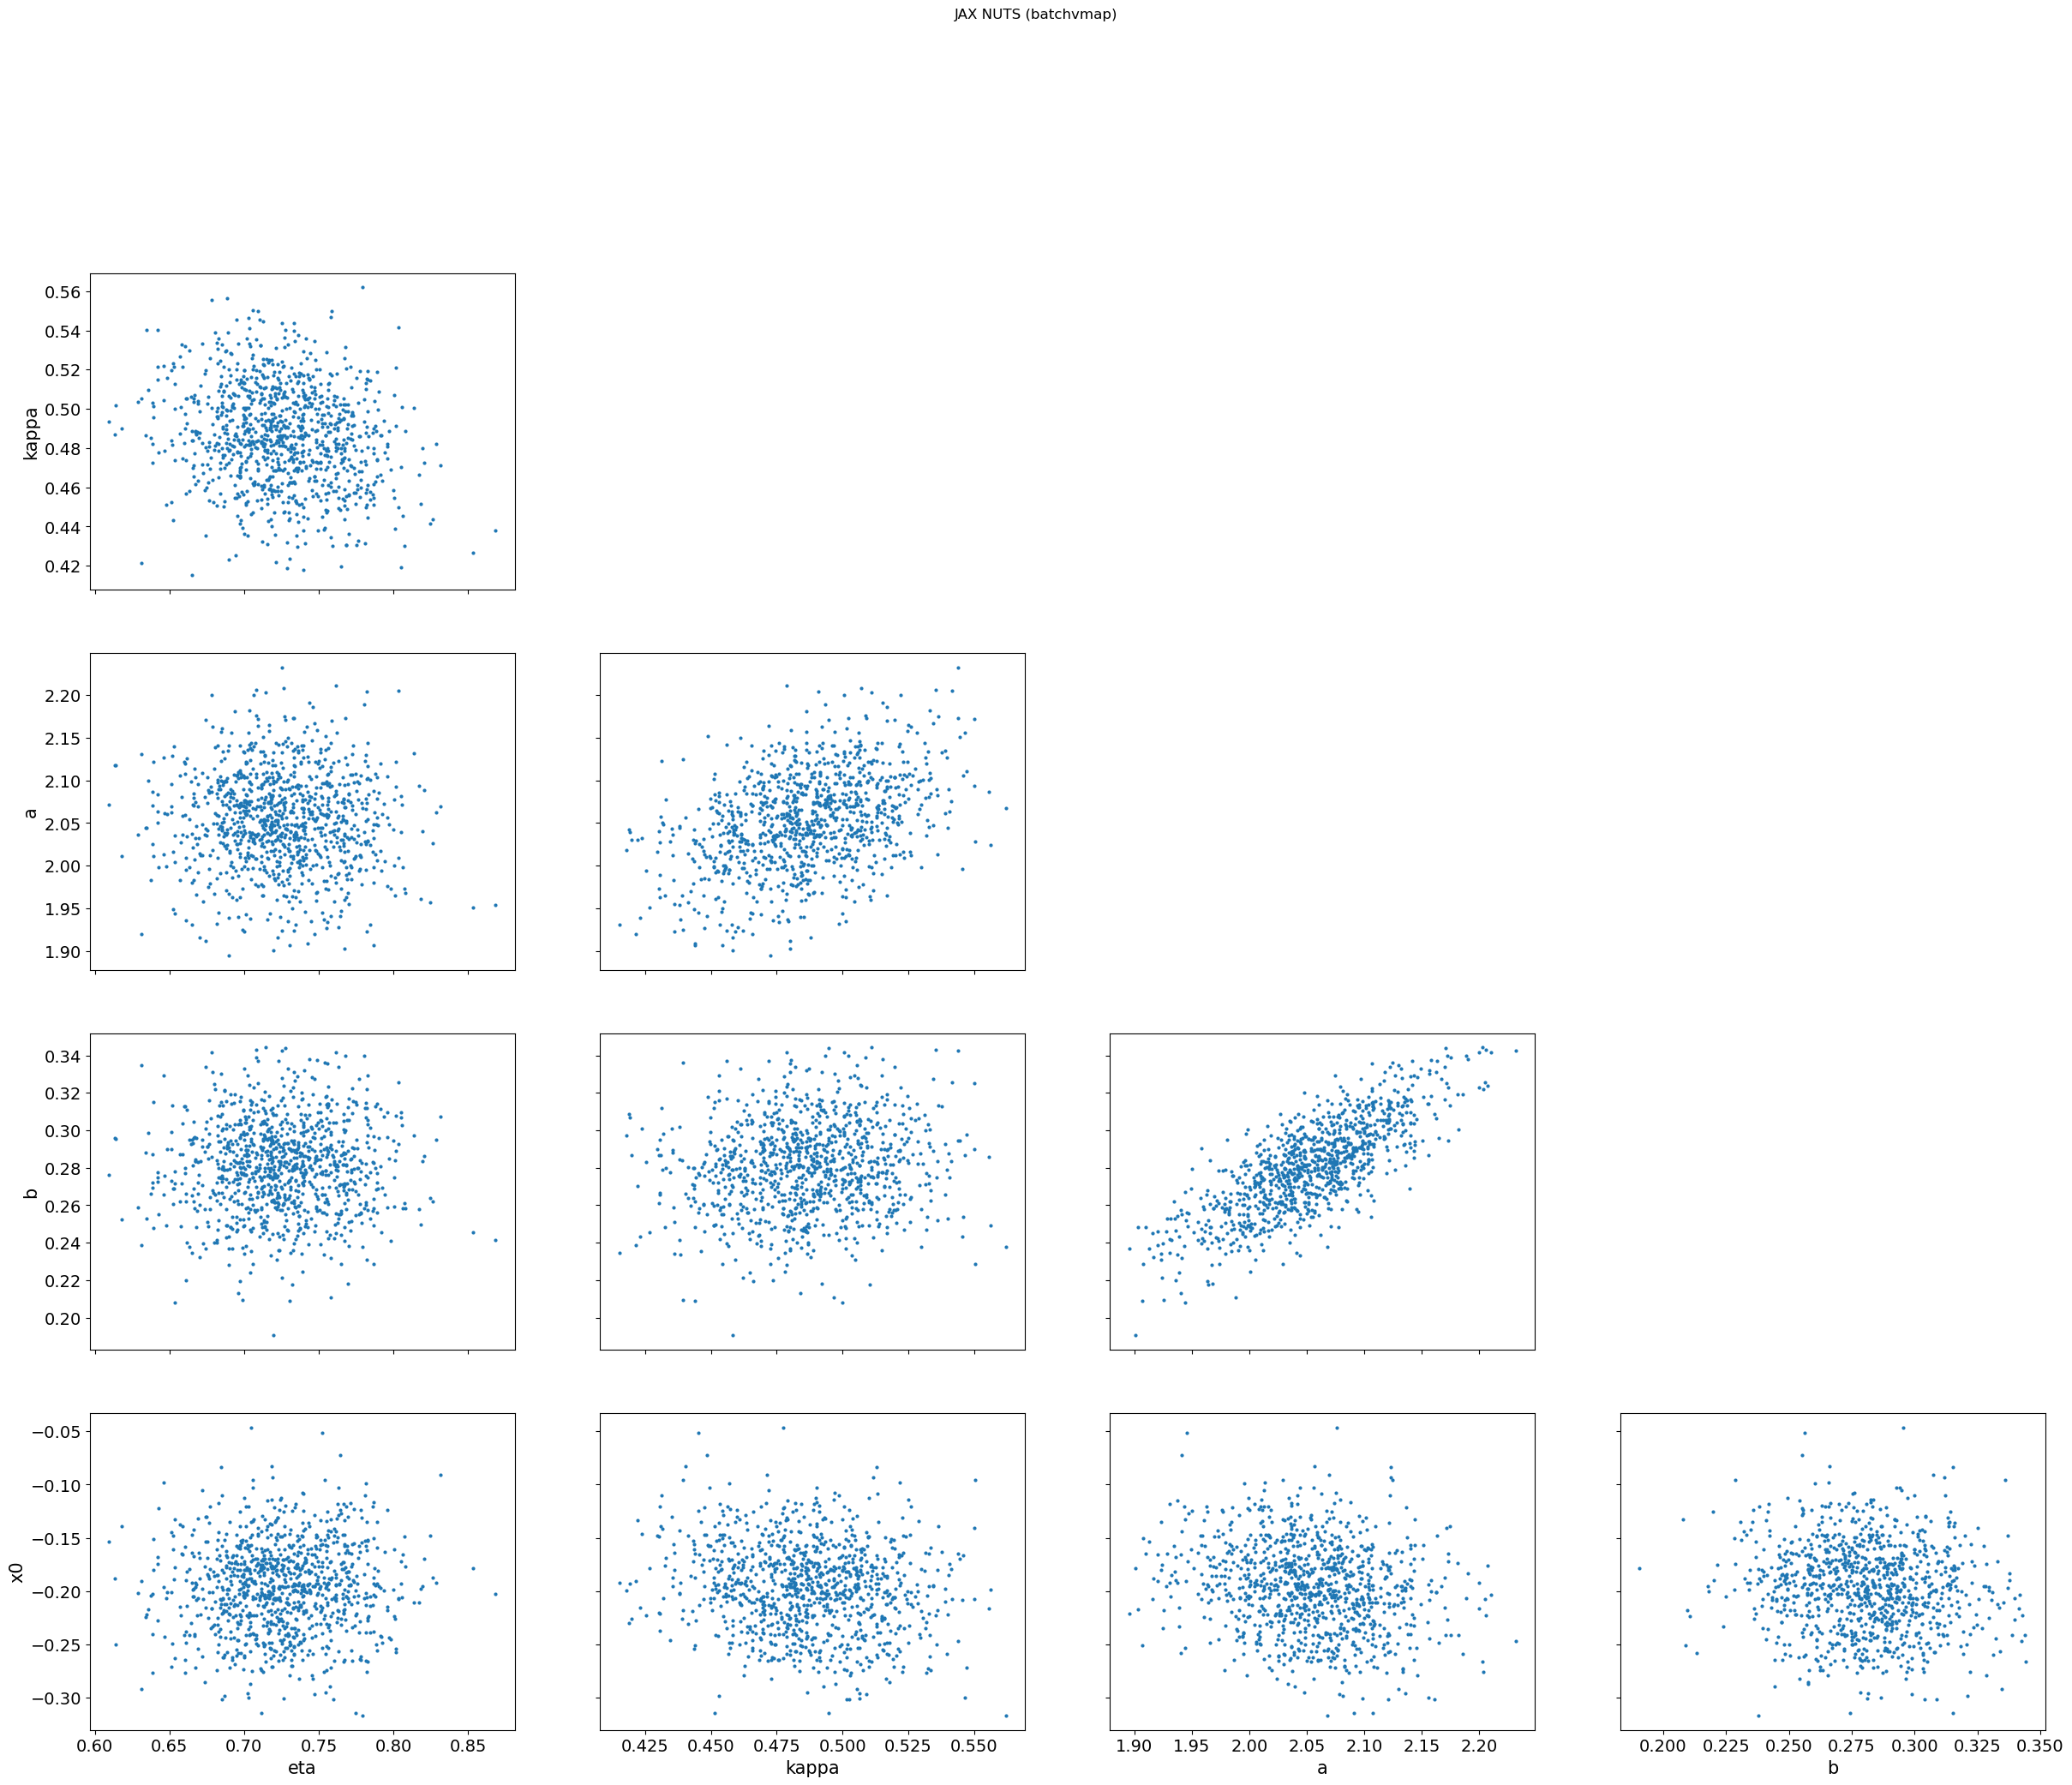

In [19]:
for vname, tr in jax_traces_renamed.items():
    az.plot_pair(tr, var_names=params)
    plt.suptitle(f"JAX NUTS ({vname})", y=1.02)
    plt.show()

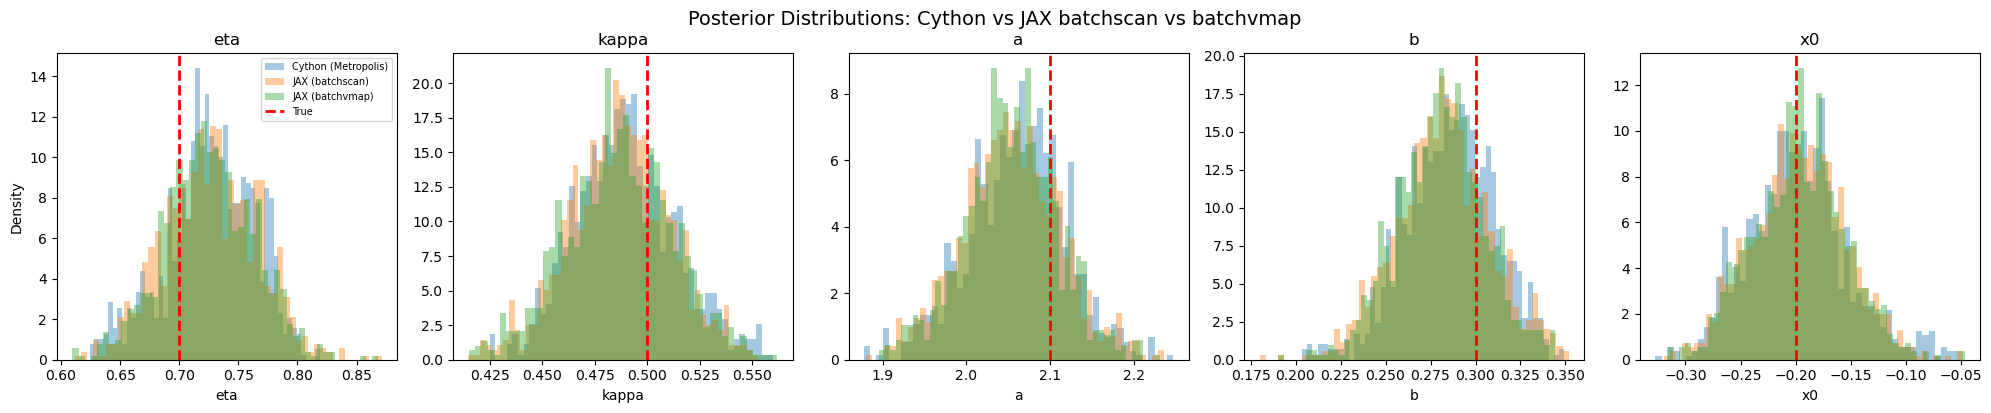

In [20]:
# Posterior comparison
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, param in enumerate(params):
    ax = axes[i]

    cy_samples = trace_cython_renamed.posterior[param].values.flatten()
    ax.hist(cy_samples, bins=50, alpha=0.4, density=True, label='Cython (Metropolis)')

    colors = ['#ff7f0e', '#2ca02c']
    for (vname, tr), color in zip(jax_traces_renamed.items(), colors):
        samples = tr.posterior[param].values.flatten()
        ax.hist(samples, bins=50, alpha=0.4, density=True, label=f'JAX ({vname})', color=color)

    ax.axvline(TRUE_PARAMS[param], color='red', linestyle='--', linewidth=2, label='True')
    ax.set_xlabel(param)
    ax.set_ylabel('Density' if i == 0 else '')
    ax.set_title(param)
    if i == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.suptitle('Posterior Distributions: Cython vs JAX batchscan vs batchvmap', y=1.02, fontsize=14)
plt.show()

In [21]:
print("\n" + "=" * 60)
print("Cython + Metropolis Summary")
print("=" * 60)
print(az.summary(trace_cython_renamed, var_names=params))


Cython + Metropolis Summary
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.727  0.037   0.646    0.785      0.005    0.002      55.0     138.0   
kappa  0.490  0.024   0.445    0.534      0.005    0.002      28.0      98.0   
a      2.061  0.058   1.942    2.159      0.008    0.005      49.0      92.0   
b      0.286  0.025   0.242    0.331      0.003    0.002      55.0     103.0   
x0    -0.197  0.045  -0.280   -0.111      0.009    0.006      26.0      39.0   

       r_hat  
eta     1.03  
kappa   1.07  
a       1.05  
b       1.04  
x0      1.07  


In [22]:
for vname, tr in jax_traces_renamed.items():
    print("\n" + "=" * 60)
    print(f"JAX + NUTS ({vname}) Summary")
    print("=" * 60)
    print(az.summary(tr, var_names=params))


JAX + NUTS (batchscan) Summary
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.727  0.040   0.655    0.796      0.001    0.001    1184.0     556.0   
kappa  0.487  0.024   0.446    0.539      0.001    0.001     915.0     766.0   
a      2.053  0.059   1.928    2.152      0.002    0.002     637.0     607.0   
b      0.282  0.026   0.234    0.334      0.001    0.001     625.0     516.0   
x0    -0.197  0.043  -0.280   -0.123      0.001    0.002     876.0     681.0   

       r_hat  
eta     1.01  
kappa   1.00  
a       1.00  
b       1.00  
x0      1.01  

JAX + NUTS (batchvmap) Summary
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.725  0.038   0.651    0.791      0.001    0.001    1280.0     540.0   
kappa  0.487  0.025   0.438    0.534      0.001    0.001     955.0     637.0   
a      2.054  0.056   1.931    2.144      0.002    0.002     745.0     628.0   
b      0.281  0.024   0.234    0.324      0.0